# Differential Privacy in FLIP-IT: Rényi accounting for ε, and the measured cost of DP-FedAvg

A rigorous deep dive into how this repository calculates, tracks, and spends its Differential
Privacy budget ε — and what that budget costs in model quality. Companion to
[`docs/PRIVACY.md`](../docs/PRIVACY.md) §3–§4, backed by [`privacy.py`](../privacy.py),
[`client_app.py`](../client_app.py) and [`server_app.py`](../server_app.py).

Four parts:

1. **The algorithm** — from $(\varepsilon, \delta)$-DP and the Gaussian mechanism to the Moments
   Accountant and Rényi DP (RDP), and the exact event chain the repo feeds to Google's
   `dp_accounting` RDP accountant each round.
2. **Dynamic ε computation** — `epsilon_from_params(noise_multiplier, clipping_norm,
   sampling_rate, rounds, delta)`: ε as a live function of the four knobs, reproduced against
   the published `results/privacy.json`.
3. **Experiment** — DP-FedAvg simulated end-to-end on the ten synthetic practices through
   Flower's real `FedAvg` strategy and its `DifferentialPrivacyServerSideFixedClipping` wrapper,
   with ε accumulated per round alongside the AUROC curve.
4. **Visualisations** — ε growth over rounds, convergence under noise, and the privacy–utility
   frontier.

Deep-learning-free, torch-free stack — logistic regression (11 parameters) is the deployed model
here, which makes every step cheap enough to run live in the notebook on synthetic data
(~2–3 minutes end to end). Absolute numbers are not a clinical claim; the *structure* of the
accounting and of the trade-off is the transferable result.

---
### Setup
```bash
uv sync --extra dev --extra notebook
uv run ckd-clinics --clinics 10          # generates data/clinics/ (already committed runs fine)
```
Headless re-run (matches `scripts/notebook.sh`):
```bash
uv run jupyter nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.timeout=600 notebooks/02_differential_privacy_epsilon.ipynb
```

In [1]:
import sys, warnings, logging, math, time, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl

# flwr logs per call at INFO; dp_accounting logs subsampled-RDP convergence notes via abseil.
# The notes mean "this Rényi order did not converge and was excluded from the minimisation"
# (dp_accounting's documented fallback) — visible once here rather than hidden.
logging.getLogger('flwr').setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── the repo's own pieces — nothing DP-related is reimplemented ─────────────
from data import load_clinic_frames
from privacy import LEARNING_RATE, NOISE_MULTIPLIERS, _array_record, _prepare, _seed_dp_noise
from dp import (
    CLIPPING_NORM, DELTA, epsilon_basic_composition, epsilon_rdp, sigma_for_epsilon,
)
from messages import evaluate_reply, hushed, train_reply
from models.protocols.common import (
    from_flower_arrays, init_weights, to_flower_arrays,
)
from server_app import weighted_and_worst
from task import compute_metrics
from flwr.serverapp.strategy import DifferentialPrivacyServerSideFixedClipping, FedAvg
from dp_accounting import dp_event, rdp

RESULTS = json.loads((ROOT / 'results' / 'privacy.json').read_text())
FRAMES = load_clinic_frames()
N_PRACTICES = len(FRAMES)
N_PATIENTS = int(sum(len(df) for df in FRAMES))
print(f'{N_PRACTICES} practices on disk, {N_PATIENTS} patients total')
print(f'project constants: clipping norm C={CLIPPING_NORM}, delta={DELTA}, LR={LEARNING_RATE}')
print(f'noise-multiplier grid: {NOISE_MULTIPLIERS}')
assert DELTA < 1.0 / N_PATIENTS, 'delta must sit below 1/n for the cohort'
print(f'delta = {DELTA:g} < 1/n = {1.0/N_PATIENTS:.2e}  → the δ ≪ 1/n convention holds')

SEEDS = [42, 43, 44, 45, 46]   # identical to results/privacy.json
ROUNDS = 20                    # identical to results/privacy.json
EPOCHS = 2                     # local partial_fit passes per round (pyproject: local-epochs)

INK, MUTED, GRID = '#141d24', '#5c6b77', '#e3e9ed'
mpl.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 130, 'font.size': 9.5,
    'axes.titlesize': 10.5, 'axes.labelsize': 9.5,
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
SIGMA_COLORS = {0.0: '#8695a1', 0.1: '#6d9dc5', 0.25: '#2a78d6',
                0.5: '#1baf7a', 1.0: '#eb9c34', 2.0: '#d64a2a'}
def sigma_color(s, cmap_name='YlOrBr'):
    return SIGMA_COLORS.get(s, '#5c6b77')
t0 = time.time()

10 practices on disk, 3276 patients total
project constants: clipping norm C=1.0, delta=1e-05, LR=0.5
noise-multiplier grid: (0.0, 0.1, 0.25, 0.5, 1.0, 2.0)
delta = 1e-05 < 1/n = 3.05e-04  → the δ ≪ 1/n convention holds


## 1 · The algorithm: how accumulated ε is actually computed

### 1.1 What $(\varepsilon, \delta)$-DP promises

A randomised mechanism $\mathcal{M}$ is $(\varepsilon, \delta)$-differentially private if for all
neighbouring datasets $D \sim D'$ (differing in one individual's record) and every measurable
output set $S$:

$$\Pr[\mathcal{M}(D) \in S] \;\leq\; e^{\varepsilon}\,\Pr[\mathcal{M}(D') \in S] \;+\; \delta$$

ε is the privacy *budget*: the log-likelihood-ratio an adversary can gain about any single
individual is bounded by $e^{\varepsilon}$; δ is a small failure probability for that bound, and by
convention must sit below $1/n$ (n = cohort size) so that "release one record outright" is not a
trivially-allowed pathology — verified for this cohort in the setup cell above (δ = $10^{-5}$,
n ≈ 3.3k).

### 1.2 The Gaussian mechanism — and where the textbook formula stops

For a function $f$ with global $\ell_2$-sensitivity $\Delta_2 = \sup_{D \sim D'} \|f(D) -
f(D')\|_2$, the Gaussian mechanism

$$\mathcal{M}(D) = f(D) + \mathcal{N}\!\left(0,\; s^2 \Delta_2^2\, I\right)$$

is $(\varepsilon, \delta)$-DP when $s \geq \sqrt{2 \ln(1.25/\delta)}\,/\,\varepsilon$
(Dwork–Roth, Thm. A.1). Two things to notice, both load-bearing for this project:

* **Validity regime.** That closed form is proved only for $\varepsilon \leq 1$. This repository's
  earlier tables quoted per-round $\varepsilon_1 = \sqrt{2\ln(1.25/\delta)}/s \approx 48$ at
  $s{=}0.1$ — far outside the regime, so the number was not conservative, it was *undefined*.
  `dp.epsilon_basic_composition` keeps that expression for the audit trail only.
* **Sensitivity here is engineered, not measured.** Flower's
  `DifferentialPrivacyServerSideFixedClipping` clips every practice's update against the broadcast
  model to $\|u_i\|_2 \leq C$ ($C$ = `CLIPPING_NORM = 1.0`). FedAvg's aggregate is the mean of
  $N$ sampled updates, so under add/remove adjacency $\Delta_2 = C/N$ — and Flower then adds
  noise with $\mathrm{std} = s \cdot C / N$
  (`flwr/supercore/differential_privacy.py::compute_stdv`, citing arXiv:1710.06963, the
  DP-FedAvg paper). The *ratio* that enters DP theory — $\mathrm{std}/\Delta_2$ — is exactly the
  **noise multiplier** $s$, whatever $C$ is. §2.2 verifies numerically that ε is invariant to $C$.

### 1.3 Composition over rounds: Moments Accountant → Rényi DP

A federated run releases not one mechanism output but $T$ of them, adaptively chosen. Composing
$(\varepsilon_1, \delta_1)$ releases linearly ("basic composition") is valid but wildly pessimistic
for hundreds of Gaussian steps: the moments-based analyses track the *shape* of the privacy-loss
distribution instead of only its worst case.

**Moments Accountant** (Abadi et al., CCS 2016, *Deep Learning with Differential Privacy*)
accumulates per-round log-moment-generating-functions of the privacy-loss random variable
$L = \log \frac{\Pr[\mathcal{M}(D)=o]}{\Pr[\mathcal{M}(D')=o]}$ and turns $\sum_t
\log \mathbb{E}[e^{\alpha L_t}]$ into a tail bound on the total loss via Markov.

**Rényi DP** (Mironov, CSF 2017) is the clean restatement of the same object that this project —
through the `dp_accounting` library — actually reports. A mechanism is $(\alpha, \rho)$-RDP if

$$D_\alpha\big(\mathcal{M}(D) \,\|\, \mathcal{M}(D')\big) \;=\; \frac{1}{\alpha-1}\log
\mathop{\mathbb{E}}_{x \sim \mathcal{M}(D')} \left[
\left(\frac{\mathcal{M}(D)(x)}{\mathcal{M}(D')(x)}\right)^{\alpha} \right] \;\leq\; \rho
\qquad \forall\, D \sim D'$$

Three theorems do all the work:

| Property | Statement | Why it matters here |
|---|---|---|
| **Gaussian RDP** | $\rho(\alpha) = \dfrac{\alpha}{2 s^2}$ (unit sensitivity, noise multiplier $s$) | one round of DP-FedAvg *is* a Gaussian release |
| **Adaptive composition** | $\rho(\alpha)$ **adds** over rounds: $\rho_T(\alpha) = \sum_t \rho_t(\alpha) = T\,\dfrac{\alpha}{2s^2}$ | ε growth with rounds is tracked per order α, not per union bound |
| **RDP → (ε, δ)** | $\varepsilon(\delta) = \min_{\alpha > 1}\; \rho_T(\alpha) + \dfrac{\log(1/\delta)}{\alpha - 1}$ | one optimisation over the whole Rényi curve, at the end |

**Subsampling amplification.** If each round only samples a fraction $q$ of practices
(Poisson sampling), each practice's privacy-loss variable flips on with probability $q$, and the
sampled-Gaussian mechanism enjoys strictly smaller $\rho(\alpha)$ — the "privacy amplification by
subsampling" of Mironov–Talwar–Zhang (2019) and Wang–Balle–Kasiviswanathan (2019). There is no
simple closed form; the accountant evaluates the exact $q$-dependent bound numerically
(`dp_accounting.rdp` computes $\log A_\alpha$ over its order grid and drops orders whose series
fail to converge — the `absl` messages filtered above). In this project `fraction-fit = 1.0`, so
$q = 1$ and nothing is credited; `dp.epsilon_rdp` exposes it as `sampling_probability`.

### 1.4 The exact chain this repo feeds the accountant

```text
one round of DP-FedAvg (flwr wrapper, noise multiplier s, q = fraction-fit)
        │
        ▼
GaussianDpEvent(s)                          ← dp_accounting.rdp: ρ(α) = α / (2 s²)
        │  if q < 1:
        ▼
PoissonSampledDpEvent(q, ·)                 ← exact sampled-Gaussian RDP, evaluated numerically
        │
        ▼
SelfComposedDpEvent(event, T)               ← ρ_T(α) = T · ρ(α)   (adaptive composition)
        │
        ▼
RdpAccountant.get_epsilon(δ = 1e-5)         ← min over its Rényi-order grid of
                                              ρ_T(α) + log(1/δ)/(α−1)
```

That is `dp.epsilon_rdp` verbatim. The project deliberately reports Google's
`dp_accounting` number rather than hand-rolled arithmetic (*"an independently maintained, widely
reviewed implementation is easier to defend to a data-protection reviewer"* — the module's own
comment). The mechanism never changed across the accounting revisions — same clipping, same noise;
only the *bookkeeping* got honest, tightening the old basic-composition figures 2–4× where both
are valid (e.g. σ = 2.0, 20 rounds: ε = 12.3 instead of 48).

## 2 · Computing ε dynamically from the four knobs

Deliverable: ε as a live function of **noise multiplier, clipping norm, sampling rate, and number
of rounds** — not a table lookup. Two layers:

* `epsilon_from_params(...)` — one-shot "(ε at round T)" for a fixed configuration, mirroring
  `dp.epsilon_rdp` but with all four parameters explicit, plus the physical quantities
  (noise std, sensitivity) that $C$ actually controls.
* `PrivacyLedger` — the *running* bookkeeper used in §3's live simulation: compose one event per
  round as it happens, read off the accumulated ε at any point.

In [2]:
class PrivacyLedger:
    # A running (epsilon, delta) ledger over federated rounds, on Google's RdpAccountant.
    # Same events as dp.epsilon_rdp, just composed one per round instead of
    # SelfComposedDpEvent(event, T) up front — the two must agree exactly (verified below).
    def __init__(self, delta=DELTA):
        self.delta = delta
        self.accountant = rdp.RdpAccountant()
        self.rounds = 0
        self.history = []          # epsilon after each composed round

    def step(self, noise_multiplier, sampling_rate=1.0):
        # Compose one more round of the sampled-Gaussian mechanism.
        if not noise_multiplier > 0:
            raise ValueError('a round with s = 0 is not a DP event; do not track it')
        event = dp_event.GaussianDpEvent(noise_multiplier)
        if sampling_rate < 1.0:
            event = dp_event.PoissonSampledDpEvent(sampling_rate, event)
        self.accountant.compose(event)
        self.rounds += 1
        self.history.append(self.epsilon())
        return self.history[-1]

    def epsilon(self):
        return float(self.accountant.get_epsilon(self.delta))


def epsilon_from_params(noise_multiplier, clipping_norm, sampling_rate, rounds,
                        delta=DELTA, num_practices=N_PRACTICES):
    # (epsilon, delta) plus the physical scale of one round's mechanism, computed
    # dynamically from all four privacy knobs.
    #
    # epsilon itself is independent of clipping_norm in Flower's parameterisation — by
    # construction: the wrapper clips updates to ||u|| <= C and sets noise std = s*C/N
    # (flwr.supercore.differential_privacy.compute_stdv), so C rescales sensitivity and
    # noise together and cancels in their ratio, which is all the accountant sees.
    # C is therefore NOT a privacy dial here; it is the utility dial (clipping bias vs
    # noise-to-signal ratio) that the accountant is blind to. Kept explicit because the
    # noise std it produces is what the model actually feels.
    n_sampled = max(1, round(sampling_rate * num_practices))
    out = {
        'noise_multiplier': noise_multiplier,
        'clipping_norm': clipping_norm,
        'sampling_rate': sampling_rate,
        'n_sampled_per_round': n_sampled,
        'rounds': rounds,
        'delta': delta,
        'epsilon': epsilon_rdp(noise_multiplier, rounds, delta=delta,
                               sampling_probability=sampling_rate),
        'epsilon_basic_upper_bound': epsilon_basic_composition(noise_multiplier, rounds, delta),
        'l2_sensitivity_mean': clipping_norm / n_sampled,          # add/remove adjacency
        'noise_std_aggregate': noise_multiplier * clipping_norm / n_sampled,  # compute_stdv
    }
    return out


# ── the two layers must agree: per-round stepping ≡ one-shot self-composition ──
_ledger = PrivacyLedger()
for _ in range(ROUNDS):
    eps_running = _ledger.step(noise_multiplier=1.0)
eps_oneshot = epsilon_rdp(1.0, ROUNDS)
print(f'ledger after {ROUNDS} rounds:  eps = {eps_running:.6f}')
print(f'one-shot epsilon_rdp(1.0, 20): eps = {eps_oneshot:.6f}')
assert math.isclose(eps_running, eps_oneshot, rel_tol=1e-12)
print('→ per-round tracking and one-shot accounting are the same object  ✓')

# ── the clipping-norm invariance, demonstrated numerically ────────────────────
for C in (0.5, 1.0, 5.0):
    r = epsilon_from_params(1.0, C, 1.0, ROUNDS)
    print(f'C={C:<4}  eps={r["epsilon"]:.6f}   '
          f'sensitivity={r["l2_sensitivity_mean"]:.4f}   noise std={r["noise_std_aggregate"]:.4f}')
print('→ eps moves not at all with C; the noise the model absorbs scales linearly with it')

ledger after 20 rounds:  eps = 30.126631
one-shot epsilon_rdp(1.0, 20): eps = 30.126631
→ per-round tracking and one-shot accounting are the same object  ✓
C=0.5   eps=30.126631   sensitivity=0.0500   noise std=0.0500
C=1.0   eps=30.126631   sensitivity=0.1000   noise std=0.1000
C=5.0   eps=30.126631   sensitivity=0.5000   noise std=0.5000
→ eps moves not at all with C; the noise the model absorbs scales linearly with it


### 2.1 Reproducing the published table exactly

`results/privacy.json` was produced by `uv run ckd-privacy --rounds 20 --seeds 42 43 44 45 46`.
The accountant side of it is reproducible in one function call per row — same σ grid, same
T = 20, same δ. The assertion at the bottom is the notebook's contract with the repo: if a future
dependency upgrade moves one digit of the accounting, this cell fails loudly instead of the docs
drifting silently.

In [3]:
pub_by_sigma = {row['noise_multiplier']: row for row in RESULTS['dp_sweep']}

rows = []
for s in [s for s in NOISE_MULTIPLIERS if s > 0]:
    r = epsilon_from_params(s, CLIPPING_NORM, sampling_rate=1.0, rounds=ROUNDS)
    pub = pub_by_sigma[s]
    rows.append({
        'sigma': s,
        'rounds': ROUNDS,
        'epsilon (live)': round(r['epsilon'], 4),
        'epsilon (published)': round(pub['epsilon'], 4),
        'basic-composition bound': round(r['epsilon_basic_upper_bound'], 1),
        'RDP tighter by': round(r['epsilon_basic_upper_bound'] / r['epsilon'], 2),
        'noise std': round(r['noise_std_aggregate'], 4),
        'match': math.isclose(r['epsilon'], pub['epsilon'], rel_tol=1e-12),
    })
table = pd.DataFrame(rows).set_index('sigma')
print(table.to_string())
assert table['match'].all(), 'live accounting diverged from results/privacy.json'
print()
print(f'all {len(table)} rows reproduce results/privacy.json exactly  ✓')
print('note: the "basic bound" at small sigma is smaller than the RDP value precisely because')
print('it is being evaluated outside its epsilon<=1 regime — it is not a valid bound there.')

       rounds  epsilon (live)  epsilon (published)  basic-composition bound  RDP tighter by  noise std  match
sigma                                                                                                        
0.10       20       1211.7783            1211.7783                    969.0            0.80      0.010   True
0.25       20        244.0355             244.0355                    387.6            1.59      0.025   True
0.50       20         81.1163              81.1163                    193.8            2.39      0.050   True
1.00       20         30.1266              30.1266                     96.9            3.22      0.100   True
2.00       20         12.3017              12.3017                     48.4            3.94      0.200   True

all 5 rows reproduce results/privacy.json exactly  ✓
note: the "basic bound" at small sigma is smaller than the RDP value precisely because
it is being evaluated outside its epsilon<=1 regime — it is not a valid bound there.


### 2.2 The two levers that move ε most: rounds and the sampling rate

With q = 1 (the repo's `fraction-fit`), the only in-model levers are σ and T. Dropping
`fraction-fit` below 1 turns on subsampling amplification — the accountant's
`PoissonSampledDpEvent` credits it exactly. Below: ε at T = 20 as q sweeps, and the
rounds-halving the project actually adopted (pyproject now defaults to 10 rounds for exactly
the reason in the last line).

In [4]:
print('ε at T=20, δ=1e-5 — sampling-rate sweep (per-round client sampling, Poisson):')
q_rows = []
for s in (1.0, 2.0):
    for q in (1.0, 0.5, 0.25, 0.1):
        q_rows.append({'sigma': s, 'q': q,
                       'epsilon': round(epsilon_rdp(s, ROUNDS, sampling_probability=q), 2)})
q_table = pd.DataFrame(q_rows).pivot(index='q', columns='sigma', values='epsilon')
q_table.columns = [f'σ={s}' for s in q_table.columns]
print(q_table.to_string())

# sanity vs the closed-form Poisson scaling intuition: at small q and moderate sigma the
# sampled-Gaussian behaves ~ quadratically in q per round before conversion — no closed form
# is used anywhere; these are all exact accountant evaluations.

e20, e10 = epsilon_rdp(2.0, 20), epsilon_rdp(2.0, 10)
print()
print(f'rounds lever at σ=2.0:   T=20 → ε={e20:.2f}      T=10 → ε={e10:.2f}')
print('halving rounds does better than halving ε, and REPORT.md shows convergence by ~round 10')
print('— which is why num-server-rounds defaults to 10 in pyproject.toml (PRIVACY.md §3.4).')

ε at T=20, δ=1e-5 — sampling-rate sweep (per-round client sampling, Poisson):


      σ=1.0  σ=2.0
q                 
0.10   4.22   1.23
0.25   9.10   3.12
0.50  16.58   6.23
1.00  30.13  12.30

rounds lever at σ=2.0:   T=20 → ε=12.30      T=10 → ε=8.08
halving rounds does better than halving ε, and REPORT.md shows convergence by ~round 10
— which is why num-server-rounds defaults to 10 in pyproject.toml (PRIVACY.md §3.4).


### 2.3 Inverting the accountant: σ from a target ε — what the live server now does

§2 runs the accountant **forwards**: pick noise σ, read off the budget ε. A deployment runs it
**backwards**: the privacy documentation commits to an (ε, δ) pair, and the noise multiplier is
*derived* for whatever round count the run is configured with. `dp.sigma_for_epsilon` is that
inversion — bisection over `epsilon_rdp`, returning the smallest σ whose composed budget stays
within target (the guarantee direction: the accountant verifies, never estimates).

This is now how the real Flower run is configured — not by noise scale but by budget:

```bash
uv run flwr run . --run-config "num-server-rounds=10 central-dp-epsilon=8"
```

`server_app.main()` computes σ = `sigma_for_epsilon(8, rounds=10, δ=1e-5)` at startup and wraps
the strategy in `DifferentialPrivacyServerSideFixedClipping` with it, logging both the σ it
derived and the accounted ε. Consequences worth stating plainly:

* **Fewer rounds automatically buy accuracy, not budget creep** — halving T halves the required
  σ at a fixed ε (the rounds lever of §2.2, applied by construction instead of by table lookup).
* **No subsampling amplification is credited in the live path** (§2.2's q-sweep stays a
  measurement instrument): FedAvg samples uniformly per round, not by Poisson inclusion, so the
  honest account composes at q = 1. `server_app` fails loudly rather than composes silently if
  `central-dp-epsilon` and `secure-aggregation` are set together — central DP needs to see what
  it clips, which SecAgg+ masks.
* The lawyer-facing sentence is therefore a constant: *"the released model is protected at
  (ε = 8, δ = 10⁻⁵), RDP-accounted"*, stable across any retuning of rounds or σ.

In [5]:
# σ derived FROM the budget, for the deployment defaults (δ = 1e-5).
# The bracket tightens the round-lever point from §2.2 with actual numbers: at a fixed
# budget, 20 rounds -> 10 rounds frees noise (sigma drops), which is accuracy returned.
rows = []
for target in (0.5, 1.0, 2.0, 4.0, 8.0, 16.0):
    sigma10 = sigma_for_epsilon(target, rounds=10)
    sigma20 = sigma_for_epsilon(target, rounds=20)
    rows.append({
        'target ε': target,
        'σ (T=10)': round(sigma10, 3),
        'σ (T=20)': round(sigma20, 3),
        'noise std per round (T=10, N=10)': round(sigma10 * CLIPPING_NORM / N_PRACTICES, 4),
        'achieved ε (T=10)': round(epsilon_rdp(sigma10, 10), 4),
    })
inv = pd.DataFrame(rows).set_index('target ε')
print(inv.to_string())

# guarantee direction, checked for every row: the accountant must certify UNDER the target
for target in inv.index:
    s = sigma_for_epsilon(target, rounds=10)
    assert epsilon_rdp(s, 10) <= target < epsilon_rdp(s * 0.99, 10)
print()
print('every derived σ certifies at-or-below its target  ✓')
print(f"anchor: target ε=8.1 at T=10 -> σ = {sigma_for_epsilon(8.1, 10):.3f} "
      f"≈ 2.0, the sweep's own measured row (PRIVACY.md §3.1)")

          σ (T=10)  σ (T=20)  noise std per round (T=10, N=10)  achieved ε (T=10)
target ε                                                                         
0.5         24.246    34.290                            2.4246                0.5
1.0         12.793    18.092                            1.2793                1.0
2.0          6.796     9.611                            0.6796                2.0
4.0          3.661     5.177                            0.3661                4.0
8.0          2.016     2.852                            0.2016                8.0
16.0         1.146     1.621                            0.1146               16.0

every derived σ certifies at-or-below its target  ✓
anchor: target ε=8.1 at T=10 -> σ = 1.996 ≈ 2.0, the sweep's own measured row (PRIVACY.md §3.1)


## 3 · Experiment: DP-FedAvg, run live, with ε stepping alongside the training curve

Protocol — identical to `privacy._dp_sweep_one_seed`, the code behind the published table:

* **Data**: the ten synthetic practices on disk (`data/clinics/`), each with its own archetype
  (urban-young, rural-elderly, metabolic, high-CVD, mixed) — a deliberately non-IID federation.
  Per-practice 80/20 split and scaler seeded from `(seed, practice)`.
* **Model**: logistic regression, 11 packed parameters (`models/protocols/common.LogRegLocal`),
  2 full-batch local epochs per round at LR 0.5, balanced class weights, L2 10⁻³.
* **Server**: Flower's real `FedAvg` strategy — all averaging is Flower's, this notebook writes
  no aggregation code (repo rule, CLAUDE.md §0.1). For σ > 0 the strategy is wrapped in
  `DifferentialPrivacyServerSideFixedClipping(σ, C=1.0, num_sampled_clients=10)`: each practice's
  update is clipped against the broadcast model, the aggregate receives Gaussian noise with
  std = σ·C/N (NumPy's global RNG, seeded per (seed, σ) cell by `privacy._seed_dp_noise` —
  the reproducibility fix from PRIVACY.md §7).
* **Metrics**: per round, sample-weighted AUROC/sensitivity *and* worst-practice AUROC via
  `server_app.weighted_and_worst` (repo rule, CLAUDE.md §0.5: never report the mean alone).
* **Accounting**: a `PrivacyLedger` steps exactly once per round, in lockstep with the releases
  the wrapper actually makes. `fraction-fit = 1.0` ⇒ q = 1, no amplification. δ = 10⁻⁵.

In [6]:
def run_dp_fedavg(sigmas, rounds=ROUNDS, seeds=SEEDS, epochs=EPOCHS):
    # One independent run per (seed, sigma) cell; per-round metrics + accumulated epsilon.
    # Mirrors privacy._dp_sweep_one_seed, additionally recording the whole curve.
    records = []
    for seed in seeds:
        locals_ = _prepare(FRAMES, seed)
        for sigma in sigmas:
            _seed_dp_noise(seed, sigma)          # noise reproducibility fix, PRIVACY.md §7
            base = FedAvg(evaluate_metrics_aggr_fn=weighted_and_worst)
            strategy = base
            ledger = None
            if sigma > 0:
                strategy = DifferentialPrivacyServerSideFixedClipping(
                    base, noise_multiplier=sigma,
                    clipping_norm=CLIPPING_NORM, num_sampled_clients=len(locals_))
                ledger = PrivacyLedger()

            w = init_weights(locals_[0].n_features)
            for rnd in range(1, rounds + 1):
                if sigma > 0:
                    # the wrapper clips against the broadcast model — tell it what that was
                    strategy.current_arrays = _array_record(w)
                replies = [
                    train_reply(
                        to_flower_arrays(loc.local_sgd(w, epochs=epochs, lr=LEARNING_RATE)),
                        loc.num_examples)
                    for loc in locals_
                ]
                with hushed():
                    arrays, _ = strategy.aggregate_train(rnd, replies)
                if arrays is None:
                    break
                w = from_flower_arrays(arrays.to_numpy_ndarrays())

                eval_replies = [
                    evaluate_reply(compute_metrics(loc.y_test, loc.test_scores(w)),
                                   len(loc.y_test), pid)
                    for pid, loc in enumerate(locals_)
                ]
                with hushed():
                    agg = dict(strategy.aggregate_evaluate(rnd, eval_replies))
                records.append({
                    'sigma': sigma, 'seed': seed, 'round': rnd,
                    'auc': agg.get('auc'), 'auc_worst': agg.get('auc_worst'),
                    'sensitivity': agg.get('sensitivity'),
                    'epsilon': ledger.step(sigma) if ledger else np.nan,
                })
    return pd.DataFrame(records)

print('defined: run_dp_fedavg(sigmas, rounds, seeds, epochs)')

defined: run_dp_fedavg(sigmas, rounds, seeds, epochs)


In [7]:
t_run = time.time()
df = run_dp_fedavg(NOISE_MULTIPLIERS)          # 6 σ × 20 rounds × 5 seeds, live
print(f'{len(df)} round-records in {time.time() - t_run:.1f}s '
      f'({len(SEEDS)} seeds × {len(NOISE_MULTIPLIERS)} noise levels × {ROUNDS} rounds)')

pd.set_option('display.width', 160)
print('\nPer-round trace for one cell (σ=1.0, seed=42) — ε accumulating round by round:')
trace = df[(df.sigma == 1.0) & (df.seed == 42)][['round', 'auc', 'auc_worst', 'epsilon']]
print(trace.round(4).to_string(index=False))

600 round-records in 10.5s (5 seeds × 6 noise levels × 20 rounds)

Per-round trace for one cell (σ=1.0, seed=42) — ε accumulating round by round:
 round    auc  auc_worst  epsilon
     1 0.7516     0.4248   4.7285
     2 0.7995     0.6391   7.0774
     3 0.7878     0.6316   9.0100
     4 0.7868     0.6170  10.7255
     5 0.7576     0.5556  12.3017
     6 0.7746     0.6000  13.7762
     7 0.7926     0.7000  15.1754
     8 0.7939     0.6889  16.5129
     9 0.7968     0.6889  17.8036
    10 0.7857     0.6444  19.0536
    11 0.7894     0.6556  20.2592
    12 0.7806     0.6222  21.4449
    13 0.7987     0.7000  22.5949
    14 0.7956     0.6667  23.7309
    15 0.7880     0.6444  24.8309
    16 0.8012     0.7111  25.9309
    17 0.7972     0.7111  26.9952
    18 0.7980     0.6832  28.0452
    19 0.8065     0.6936  29.0952
    20 0.8057     0.6874  30.1266


In [8]:
final = df[df['round'] == ROUNDS]
# np.std (ddof=0), not pandas' ddof=1: the convention privacy.py reports, so the table
# below is digit-identical with docs/PRIVACY.md §3.1
summary = (final.groupby('sigma')
           .agg(auc_mean=('auc', 'mean'), auc_std=('auc', np.std),
                worst_mean=('auc_worst', 'mean'), worst_std=('auc_worst', np.std),
                epsilon=('epsilon', 'first'))
           .reset_index())
summary['epsilon(live)'] = summary['epsilon'].apply(
    lambda e: '—' if pd.isna(e) else f'{e:.2f}')
summary['epsilon(pub)'] = summary['sigma'].map(
    lambda s: '—' if not pub_by_sigma[s]['epsilon'] else f"{pub_by_sigma[s]['epsilon']:.2f}")
summary['AUROC'] = summary.apply(lambda r: f"{r.auc_mean:.3f}±{r.auc_std:.3f}", axis=1)
summary['worst practice'] = summary.apply(
    lambda r: f"{r.worst_mean:.3f}±{r.worst_std:.3f}", axis=1)
print(summary[['sigma', 'AUROC', 'worst practice', 'epsilon(live)', 'epsilon(pub)']]
      .to_string(index=False))

# the live run re-creates the published utility numbers (same code path, same five seeds)
for _, r in summary.iterrows():
    assert math.isclose(r.auc_mean, pub_by_sigma[r.sigma]['auc_mean'], abs_tol=1e-9), r.sigma
print('\nall σ rows match results/privacy.json to 1e-9 — deterministic reproduction  ✓')

 sigma       AUROC worst practice epsilon(live) epsilon(pub)
  0.00 0.808±0.008    0.675±0.054             —            —
  0.10 0.808±0.007    0.676±0.056       1211.78      1211.78
  0.25 0.807±0.008    0.669±0.054        244.04       244.04
  0.50 0.803±0.011    0.681±0.033         81.12        81.12
  1.00 0.794±0.014    0.646±0.061         30.13        30.13
  2.00 0.773±0.017    0.608±0.097         12.30        12.30

all σ rows match results/privacy.json to 1e-9 — deterministic reproduction  ✓


## 4 · What the accountant and the training loop say together

* **Fig. 1 — ε growth.** Log-scale ε(T) per noise multiplier, from the accountant alone
  (no training needed — this curve is a property of the mechanism, the round count, and δ).
  The dashed line is the invalid-but-instructive basic composition at σ = 2.0.
* **Fig. 2 — convergence under DP.** Live per-round AUROC (left) and worst-practice AUROC
  (right), mean ± s.d. over the five seeds, with each curve's final composed ε in the legend.
* **Fig. 3 — the frontier.** Final-round utility as a function of the budget actually spent,
  with the rounds-lever arrow the project already shipped (20 → 10 rounds at σ = 2.0).

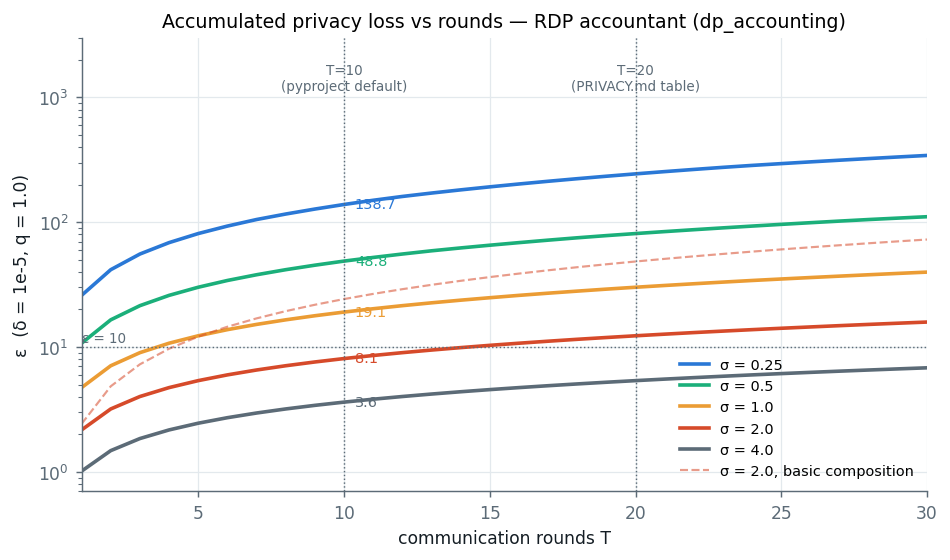

reading: within the measured grid, only σ ≳ 2 keeps ε near single digits at T=20;
and RDP sits ~4× below the (regime-violating) basic-composition line for the same noise.


In [9]:
# ── Fig 1 · epsilon growth over communication rounds ─────────────────────────
T = np.arange(1, 31)
fig, ax = plt.subplots(figsize=(7.4, 4.4))
for s in (0.25, 0.5, 1.0, 2.0, 4.0):
    eps_curve = [epsilon_rdp(s, int(t)) for t in T]
    ax.plot(T, eps_curve, color=sigma_color(s, 'kos'), lw=2,
            label=f'σ = {s}')
    ax.annotate(f'{eps_curve[9]:.1f}', (10, eps_curve[9]), textcoords='offset points',
                xytext=(6, -2), fontsize=8, color=sigma_color(s, 'kos'))
ax.plot(T, [epsilon_basic_composition(2.0, int(t)) for t in T], ls='--', lw=1.2,
        color=sigma_color(2.0, 'kos'), alpha=0.55, label='σ = 2.0, basic composition')
for x, name in ((10, 'pyproject default'), (20, 'PRIVACY.md table')):
    ax.axvline(x, color=MUTED, lw=0.8, ls=':')
    ax.annotate(f'T={x}\n({name})', (x, 1.15e3), ha='center', fontsize=7.5, color=MUTED)
ax.axhline(10, color=MUTED, lw=0.8, ls=':')
ax.annotate('ε = 10', (1.0, 11), fontsize=7.5, color=MUTED)
ax.set_yscale('log')
ax.set_xlabel('communication rounds T')
ax.set_ylabel('ε  (δ = 1e-5, q = 1.0)')
ax.set_title('Accumulated privacy loss vs rounds — RDP accountant (dp_accounting)')
ax.set_ylim(0.7, 3e3)
ax.set_xlim(1, 30)
ax.legend(frameon=False, fontsize=8, loc='lower right')
fig.tight_layout()
plt.show()
print('reading: within the measured grid, only σ ≳ 2 keeps ε near single digits at T=20;')
print('and RDP sits ~4× below the (regime-violating) basic-composition line for the same noise.')

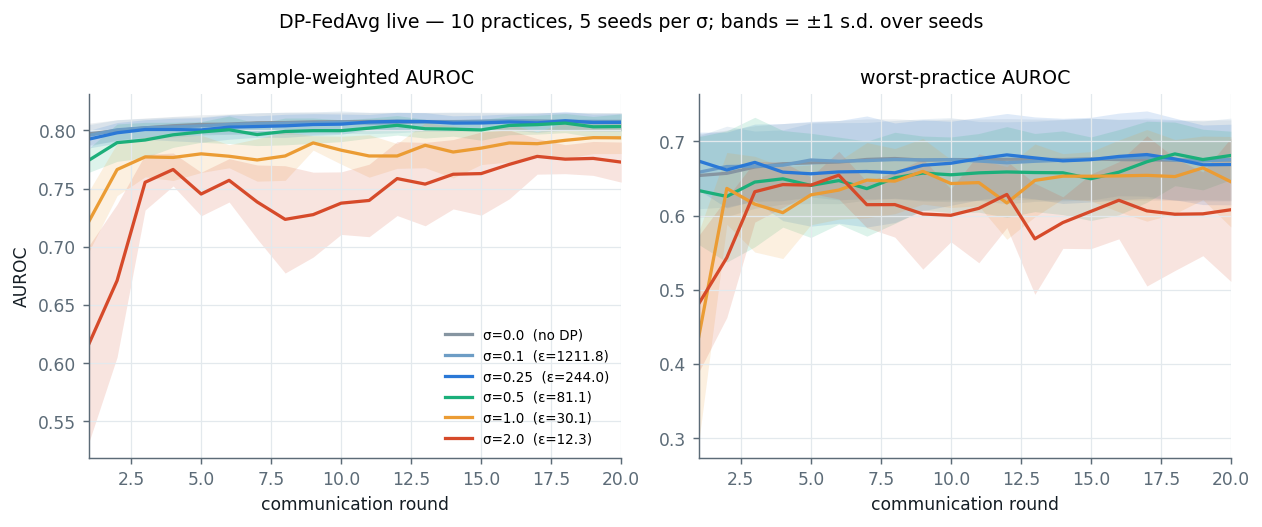

reading: convergence is reached by ~round 10 at every σ; what σ buys after that is
mostly privacy loss, not accuracy — the quantitative version of the rounds lever.


In [10]:
# ── Fig 2 · convergence under DP: utility trajectories alongside spent ε ─────
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.0), sharex=True)
for ax, metric, title in ((axes[0], 'auc', 'sample-weighted AUROC'),
                          (axes[1], 'auc_worst', 'worst-practice AUROC')):
    for s in NOISE_MULTIPLIERS:
        g = df[df.sigma == s].groupby('round')[metric]
        mu, sd = g.mean(), g.std(ddof=0)
        eps_label = 'no DP' if s == 0 else f'ε={epsilon_rdp(s, ROUNDS):.1f}'
        ax.plot(mu.index, mu.values, lw=1.8, color=sigma_color(s, 'kos'),
                label=f'σ={s}  ({eps_label})')
        ax.fill_between(mu.index, mu - sd, mu + sd, alpha=0.15,
                        color=sigma_color(s, 'kos'), lw=0)
    ax.set_xlabel('communication round')
    ax.set_title(title)
    ax.set_xlim(1, ROUNDS)
axes[0].set_ylabel('AUROC')
axes[0].legend(frameon=False, fontsize=7.5, loc='lower right')
fig.suptitle('DP-FedAvg live — 10 practices, 5 seeds per σ; bands = ±1 s.d. over seeds',
             y=1.0, fontsize=10.5)
fig.tight_layout()
plt.show()
print('reading: convergence is reached by ~round 10 at every σ; what σ buys after that is')
print('mostly privacy loss, not accuracy — the quantitative version of the rounds lever.')

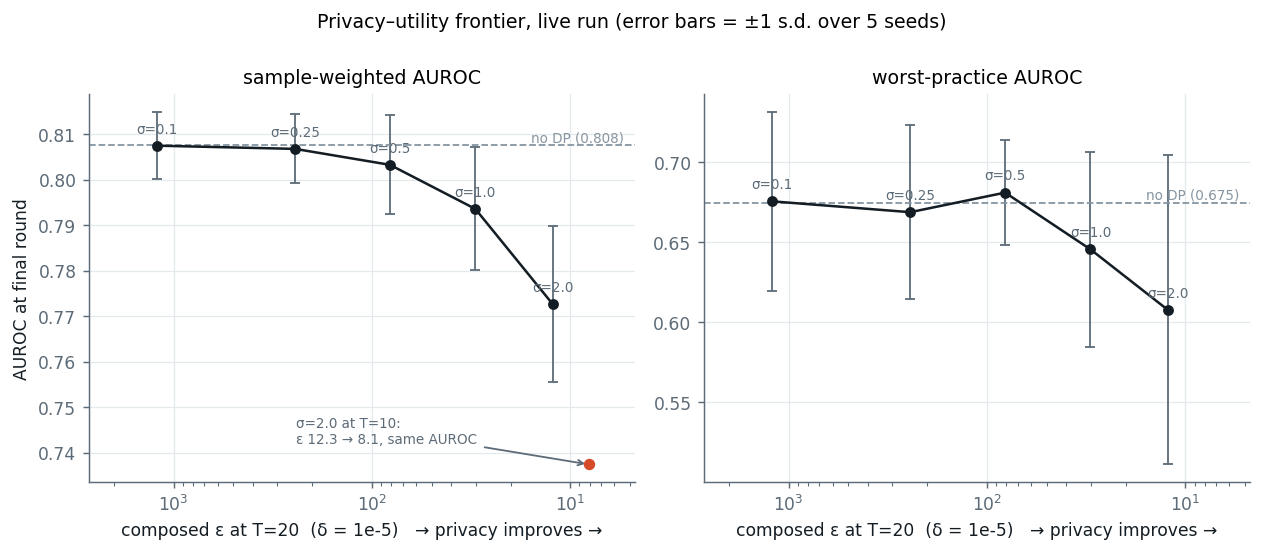

reading: the frontier is shallow until ε ≈ 12 on this cohort — central DP is nearly
free at large budgets — and drops off a cliff below. Where the cliff sits moves with
cohort size, practice count and rounds, which is why this is measured, not assumed.


In [11]:
# ── Fig 3 · the privacy–utility frontier ─────────────────────────────────────
pts = summary[summary.sigma > 0]
eps_min, eps_max = pts['epsilon'].min(), pts['epsilon'].max()

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.2))
for ax, metric_mean, metric_std, title in (
        (axes[0], 'auc_mean', 'auc_std', 'sample-weighted AUROC'),
        (axes[1], 'worst_mean', 'worst_std', 'worst-practice AUROC')):
    ax.errorbar(pts['epsilon'], pts[metric_mean], yerr=pts[metric_std],
                fmt='o-', color=INK, ecolor=MUTED, elinewidth=1, capsize=3, ms=5, lw=1.4)
    for _, r in pts.iterrows():
        ax.annotate(f'σ={r.sigma}', (r['epsilon'], r[metric_mean]),
                    textcoords='offset points', xytext=(0, 7), ha='center',
                    fontsize=7.5, color=MUTED)
    ceil = summary.loc[summary.sigma == 0, metric_mean].iloc[0]
    ax.axhline(ceil, color=sigma_color(0.0, 'kos'), ls='--', lw=1)
    # x in axes fraction, y in data coords: the label can never fall off the edge
    ax.annotate(f'no DP ({ceil:.3f})', xy=(0.98, ceil), xycoords=('axes fraction', 'data'),
                va='bottom', ha='right', fontsize=7.5, color=sigma_color(0.0, 'kos'))
    ax.set_xscale('log')
    # set limits explicitly BEFORE inverting, with log-space padding so the σ labels at
    # the extreme budgets stay inside the axes
    ax.set_xlim(eps_max * 2.2, eps_min / 2.6)   # privacy improves →
    ax.set_xlabel('composed ε at T=20  (δ = 1e-5)   → privacy improves →')
    ax.set_title(title)

# the lever the project actually shipped: 20 → 10 rounds at σ=2.0 costs no measured
# accuracy but cuts ε from 12.30 to 8.08 (values from the live df, not from memory)
m10 = df[(df.sigma == 2.0) & (df['round'] == 10)]['auc'].mean()
m20 = summary.loc[summary.sigma == 2.0, 'auc_mean'].iloc[0]
axes[0].annotate('σ=2.0 at T=10:\nε 12.3 → 8.1, same AUROC',
                 xy=(epsilon_rdp(2.0, 10), m10), xycoords='data',
                 xytext=(0.38, 0.10), textcoords='axes fraction',
                 fontsize=7.5, color=MUTED, ha='left',
                 arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.0))
axes[0].scatter([epsilon_rdp(2.0, 10)], [m10], color='#d64a2a', zorder=5, s=28)
axes[0].set_ylabel('AUROC at final round')
fig.suptitle('Privacy–utility frontier, live run (error bars = ±1 s.d. over 5 seeds)',
             y=1.0, fontsize=10.5)
fig.tight_layout()
plt.show()
print('reading: the frontier is shallow until ε ≈ 12 on this cohort — central DP is nearly')
print('free at large budgets — and drops off a cliff below. Where the cliff sits moves with')
print('cohort size, practice count and rounds, which is why this is measured, not assumed.')

## 5 · Findings and honest limits

**What the numbers above establish, live:**

1. **The accountant is RDP over the exact sampled-Gaussian chain** — `GaussianDpEvent(σ)` →
   (optionally `PoissonSampledDpEvent(q, ·)`) → `SelfComposedDpEvent(·, T)` →
   `RdpAccountant.get_epsilon(δ)`, i.e. the Moments-Accountant lineage bookkeeping every Rényi
   order and converting once. Basic composition over the same mechanism is 2–4× looser where it
   is valid at all, and undefined for most of this σ grid.
2. **Of the four knobs, ε sees three**: noise multiplier σ, sampling rate q, rounds T (and δ).
   Clipping norm C is invisible to the accountant because Flower couples the noise std to it
   (std = σ·C/N) — C is a *utility* parameter (clipping bias vs noise-to-signal), not a privacy
   one, in this parameterisation.
3. **Rounds are the cheapest lever**: the live curves plateau by ~round 10 at every σ, and
   cutting T 20 → 10 at σ = 2.0 moves ε 12.3 → 8.1 with no measured AUROC change (Fig. 3 arrow).
   q < 1 helps further (2.2) but is not yet how the federation runs (`fraction-fit = 1.0`).
4. **On this cohort, central DP-FedAvg is nearly free until ε ≈ 12**, then pays steeply.

**Limits — read before quoting any ε:**

* **Central DP's threat model.** The wrapper noises *at aggregation*; the SuperLink still
  receives every practice's un-noised update first. Only `LocalDpMod` changes what the
  aggregating party sees, and its cost at 10 practices is severe (PRIVACY.md §3.2–3.3: worst
  practice collapses to 0.397 at ε ≈ 4.3). The ε numbers here constrain inference from the
  *released model*, nothing more.
* **Adjacency convention.** The accountant composes under add/remove-one adjacency
  (`dp_accounting` default) with sensitivity C on the clipped update — consistent with the
  DP-FedAvg convention (arXiv:1710.06963). A replace-one guarantee would cost a factor of 2 in
  sensitivity and must be stated as such if ever claimed.
* **Synthetic data.** The frontier's *knee position* is a property of this cohort, feature set
  and 11-parameter model. The audit section of PRIVACY.md §5 shows membership-inference finds no
  signal even without DP on this model class — DP's utility price here is being paid against a
  threat the model's capacity already bounds. That is an argument about *this* model, not a
  licence to skip DP on richer real data.
* **δ choice.** δ = 10⁻⁵ satisfies δ ≪ 1/n (checked live, §0). On the pilot's larger real cohort
  1/n shrinks further, so δ stays comfortable; it must be re-checked, not assumed.

### References

* Dwork & Roth, *The Algorithmic Foundations of Differential Privacy*, FnT-TCS 2014
  (Gaussian mechanism, Thm. A.1).
* Abadi et al., *Deep Learning with Differential Privacy*, CCS 2016 — the Moments Accountant.
* Mironov, *Rényi Differential Privacy*, CSF 2017 — the accountant this repo reports.
* Mironov, Talwar & Zhang, *Rényi DP of the Sampled Gaussian Mechanism*, 2019 (arXiv:1908.10530).
* Wang, Balle & Kasiviswanathan, *Subsampled RDP and Analytical Moments Accountant*, AISTATS 2019.
* McMahan et al., *Learning Differentially Private Recurrent Language Models*, ICLR 2018
  (arXiv:1710.06963) — the DP-FedAvg parameterisation Flower's `compute_stdv` implements.
* Google, [`dp_accounting`](https://github.com/google/differential-privacy) — the implementation
  behind every ε printed above; Flower [`DifferentialPrivacyServerSideFixedClipping`](
  https://flower.ai/docs/framework/ref-api/flwr.serverapp.strategy.DifferentialPrivacyServerSideFixedClipping.html).